# Images as Tensors and Why CNNs Work

## Start with the problem: turn a picture into meaningful calculations

Imagine recognizing a red marker in camera images even when its position changes. To a person, it is a picture with colors and nearby edges. To an artificial neural network, it is an array of measurements. The model can only use the information if pixel scale, channel order, and spatial axes have consistent meanings.

This lesson returns to the image representation beneath the earlier CNN projects. We build an RGB image from numbers, convert it to a PyTorch tensor, trace a color detector and its learning update, and test how local filters respond to shifts. Every image is constructed locally, so the notebook needs no downloads.

The calculations use hand-chosen weights to expose the mechanisms. They show why convolution is a useful architectural assumption, not that a particular classifier has been trained or validated on real photographs.

The [companion notes](20_Images_as_Tensors_and_Why_CNNs_Work_Notes.ipynb) include the diagrams. These are CPU calculations and controlled demonstrations, not a trained-model accuracy experiment.

In [1]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(18)
torch.set_num_threads(1)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('CPU | constructed images | hand-set filters and one illustrative update')

CPU | constructed images | hand-set filters and one illustrative update


## Name the meaning of every pixel and axis

A grayscale pixel has one intensity. An RGB pixel has three measurements, in red, green, blue order. In an 8-bit RGB array, each measurement is an integer from zero to 255. A red pixel is $[255,0,0]$, a green pixel is $[0,255,0]$, and a white pixel is $[255,255,255]$. These are channel values, not three separate images of different objects.

Many image arrays use height × width × channels, abbreviated HWC. PyTorch's ordinary 2D convolution accepts batches in NCHW order: number of images, channels, height, width. One 4 × 4 RGB image therefore becomes shape `(1, 3, 4, 4)`.

For HWC data, `image[row, column, channel]` selects a measurement. For NCHW, `batch[example, channel, row, column]` selects the same value. Row zero is the top of the displayed array and column zero is its left side. The array does not automatically tell a model what a channel or dimension means; the data pipeline establishes that convention.

The range 0–255 is a property of this example, not a universal rule. Scientific images, floating-point images, and higher-bit-depth data may use other ranges. Grayscale, RGB, BGR, and RGBA are different input contracts. An extra alpha channel is transparency information and cannot silently stand in for a learned RGB channel.

HWC shape: (4, 4, 3) | dtype: uint8
Top-left pixel [R, G, B]: [255, 0, 0]


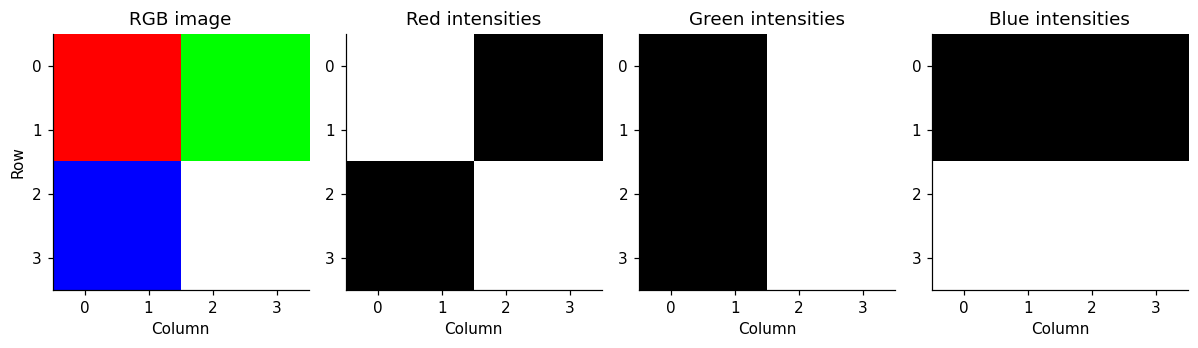

In [2]:
rgb_hwc = np.zeros((4, 4, 3), dtype=np.uint8)
rgb_hwc[:2, :2] = [255, 0, 0]
rgb_hwc[:2, 2:] = [0, 255, 0]
rgb_hwc[2:, :2] = [0, 0, 255]
rgb_hwc[2:, 2:] = [255, 255, 255]
assert rgb_hwc[0, 0].tolist() == [255, 0, 0]
assert rgb_hwc[3, 3].tolist() == [255, 255, 255]
print('HWC shape:', rgb_hwc.shape, '| dtype:', rgb_hwc.dtype)
print('Top-left pixel [R, G, B]:', rgb_hwc[0, 0].tolist())
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
axes[0].imshow(rgb_hwc); axes[0].set_title('RGB image')
for channel, ax in enumerate(axes[1:]):
    ax.imshow(rgb_hwc[:, :, channel], cmap='gray', vmin=0, vmax=255)
    ax.set_title(['Red intensities', 'Green intensities', 'Blue intensities'][channel])
for ax in axes:
    ax.set_xticks(range(4)); ax.set_yticks(range(4)); ax.set_xlabel('Column')
axes[0].set_ylabel('Row')
plt.tight_layout(); plt.show()

## Change the axis order without changing the picture

To move from HWC to CHW, reorder axes as `(2, 0, 1)`, then add the batch axis. This moves the channel dimension to the front while preserving each pixel's identity. `permute` expresses this operation in PyTorch.

`reshape` instead regroups elements according to their logical order. Asking for shape `(3,4,4)` does not tell it to move each pixel's red value into one red plane. The first HWC values include red, green, and blue from neighboring pixels; simply regrouping them mixes their meanings. A shape can be accepted by a layer while representing the wrong image.

The correct mapping satisfies $X[0,c,r,w]=I[r,w,c]/255$ for every channel $c$, row $r$, and column $w$. The code verifies every entry, not just the final dimensions. Converting back with the inverse permutation must reproduce the displayed picture. A permutation may produce a non-contiguous view; `contiguous()` changes storage layout, not the intended axis meaning.

NCHW shape: (1, 3, 4, 4) | correct first pixel: [1.0, 0.0, 0.0]
Reshape-only first pixel: [1.0, 0.0, 1.0]


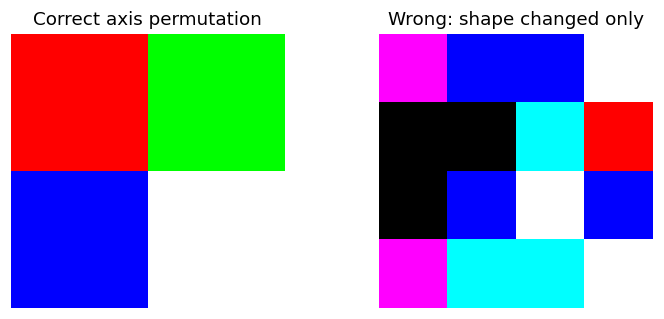

In [3]:
unit_hwc = torch.from_numpy(rgb_hwc).to(torch.float32) / 255.0
image = unit_hwc.permute(2, 0, 1).unsqueeze(0).contiguous()
wrong_image = unit_hwc.reshape(1, 3, 4, 4)
assert image.shape == wrong_image.shape == (1, 3, 4, 4)
assert not torch.equal(image, wrong_image)
for row in range(4):
    for column in range(4):
        torch.testing.assert_close(image[0, :, row, column], unit_hwc[row, column])
recovered_hwc = image[0].permute(1, 2, 0)
torch.testing.assert_close(recovered_hwc, unit_hwc)
print('NCHW shape:', tuple(image.shape), '| correct first pixel:', image[0, :, 0, 0].tolist())
print('Reshape-only first pixel:', wrong_image[0, :, 0, 0].tolist())
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(recovered_hwc); axes[0].set_title('Correct axis permutation')
axes[1].imshow(wrong_image[0].permute(1, 2, 0)); axes[1].set_title('Wrong: shape changed only')
for ax in axes:ax.axis('off')
plt.tight_layout(); plt.show()

## Scale intensities deliberately and keep that rule at prediction time

Convert unsigned integers to floating point before arithmetic. In this 8-bit example, divide by 255: $[0,128,255]$ becomes approximately $[0,0.501961,1]$. The mid-value is not exactly 0.5. Subtraction in an unsigned 8-bit type can wrap around instead of producing the intended negative number.

**Rescaling** to a known range differs from **standardization** using a mean and standard deviation. For a separate illustrative RGB pixel $[0.8,0.2,0.1]$, suppose training-channel means are $[0.5,0.25,0.75]$ and standard deviations are $[0.25,0.25,0.5]$. Then

$$x'=[(0.8-0.5)/0.25,(0.2-0.25)/0.25,(0.1-0.75)/0.5]=[1.2,-0.2,-1.3].$$

These are deviations in units of the training standard deviation, not probabilities. Negative values are valid. Means and scales are illustrative constants here; if estimated in a project, fit them on training data only. Reuse the same values during validation, testing, and inference. For a pretrained model, match its specified preprocessing rather than inventing a different rule.

Per-channel constants should have shape `(1, C, 1, 1)` when broadcasting across NCHW inputs. To display a standardized RGB image, undo the transformation first: $x=x'\sigma+\mu$. Display clipping must not be confused with the model's input transformation.

In [4]:
levels = torch.tensor([0, 128, 255], dtype=torch.uint8)
scaled = levels.float() / 255.0
torch.testing.assert_close(scaled, torch.tensor([0., 128/255, 1.]))
pixel = torch.tensor([0.8, 0.2, 0.1]).reshape(1, 3, 1, 1)
mean = torch.tensor([0.5, 0.25, 0.75]).reshape(1, 3, 1, 1)
std = torch.tensor([0.25, 0.25, 0.5]).reshape(1, 3, 1, 1)
standardized = (pixel - mean) / std
torch.testing.assert_close(standardized.flatten(), torch.tensor([1.2, -0.2, -1.3]))
torch.testing.assert_close(standardized * std + mean, pixel)
print('Rescaled integer levels:', scaled.tolist())
print('Standardized illustrative pixel:', standardized.flatten().tolist())
print('Unsigned zero minus one:', (torch.tensor(0, dtype=torch.uint8)-1).item())
print('Float zero minus one:', (torch.tensor(0, dtype=torch.uint8).float()-1).item())

Rescaled integer levels: [0.0, 0.501960813999176, 1.0]
Standardized illustrative pixel: [1.2000000476837158, -0.19999998807907104, -1.2999999523162842]
Unsigned zero minus one: 255
Float zero minus one: -1.0


## Let an ANN turn channel values into evidence

A 1 × 1 convolution can compare channels at each location. It does not inspect neighboring pixels. For the pixel $[R,G,B]=[0.8,0.2,0.1]$, choose weights $[1,-0.5,-0.5]$ and bias $-0.2$:

$$z=0.8(1)+0.2(-0.5)+0.1(-0.5)-0.2=0.45.$$

ReLU retains $h=0.45$. This hand-set detector favors red relative to green and blue. Apply the same weights to a pure green pixel $[0,1,0]$: its score is $0-0.5-0-0.2=-0.7$, and ReLU returns zero. One shared rule can create a red-evidence map over the entire image.

For an illustrative two-class head, use fixed logits $[h,0]$, where class zero means the desired red-like outcome. Softmax gives $p_0=e^{0.45}/(e^{0.45}+1)\approx0.610639$. If the target is class zero, cross-entropy is approximately $0.493249$.

The score derivative is $p_0-1\approx-0.389361$. ReLU passes it because the score is positive. Weight gradients are the score derivative times each input: approximately $[-0.311489,-0.077872,-0.038936]$. The bias gradient is $-0.389361$.

At SGD rate $0.1$, updated weights are approximately $[1.031149,-0.492213,-0.496106]$ and bias is $-0.161064$. The updated score is about $0.515802$, increasing probability on the target class. The code calculates the new loss. This is the full learning mechanism for a one-pixel CNN detector, not evidence that the hand-set rule reliably identifies real markers under changing lighting.

In [5]:
detector = nn.Conv2d(3, 1, kernel_size=1).double()
with torch.no_grad():
    detector.weight.copy_(torch.tensor([1., -0.5, -0.5], dtype=torch.float64).reshape(1, 3, 1, 1))
    detector.bias.fill_(-0.2)
one_pixel = torch.tensor([0.8, 0.2, 0.1], dtype=torch.float64).reshape(1, 3, 1, 1)
score = detector(one_pixel).relu().reshape(1)
logits = torch.stack([score, torch.zeros_like(score)], dim=1)
loss = F.cross_entropy(logits, torch.tensor([0]))
loss.backward()
score_gradient = logits.detach().softmax(1)[0, 0] - 1
torch.testing.assert_close(detector.weight.grad.flatten(), score_gradient * one_pixel.flatten())
torch.testing.assert_close(detector.bias.grad, score_gradient.reshape(1))
old_weight = detector.weight.detach().clone()
old_bias = detector.bias.detach().clone()
with torch.no_grad():
    detector.weight -= 0.1 * detector.weight.grad
    detector.bias -= 0.1 * detector.bias.grad
    new_score = detector(one_pixel).relu().reshape(1)
    new_logits = torch.stack([new_score, torch.zeros_like(new_score)], dim=1)
    new_loss = F.cross_entropy(new_logits, torch.tensor([0]))
    original_map = F.conv2d(image.double(), old_weight, old_bias).relu()
assert new_loss < loss
torch.testing.assert_close(score.detach(), torch.tensor([0.45], dtype=torch.float64))
print('Old/new score:', score.item(), new_score.item())
print('Old/new loss:', loss.item(), new_loss.item())
print('Original red-evidence map:\n', original_map[0, 0])

Old/new score: 0.45 0.5158019694625815
Old/new loss: 0.49324894599745484 0.46814040043680644
Original red-evidence map:
 tensor([[0.8000, 0.8000, 0.0000, 0.0000],
        [0.8000, 0.8000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000]], dtype=torch.float64)


## Locality: why neighboring values belong in the same calculation

A red color alone does not describe a shape. A 3 × 3 filter sees a small spatial neighborhood, so it can compare patterns such as a bright stroke beside dark pixels. Each output filter spans all input channels, adds their weighted contributions, and produces one feature-map value per location.

For a grayscale patch $[[0,0,1],[0,0,1],[0,0,1]]$ and kernel $[[-1,0,1],[-1,0,1],[-1,0,1]]$, each row contributes $0(-1)+0(0)+1(1)=1$, giving output three. Reversing the bright and dark sides changes the response to minus three. The sign records a direction of contrast; ReLU would keep only the positive direction unless another filter captured the opposite one.

Flattening an image does not destroy its values, but an ordinary dense layer does not explicitly enforce local connectivity or weight sharing. For a 32 × 32 RGB image, a dense map to 128 values needs $(3\times32\times32)(128)+128=393344$ parameters. A 3 × 3 convolution from three to sixteen channels needs $16(3\times3\times3+1)=448$. With padding one it produces sixteen 32 × 32 maps, not 128 values, so these are different layers, not equivalent models with different costs.

The architectural assumption is that local patterns can be useful at several locations. This often matches images, but can be unsuitable for an arbitrary table whose neighboring columns have unrelated meanings.

In [6]:
patch = torch.tensor([[[[0., 0., 1.], [0., 0., 1.], [0., 0., 1.]]]])
edge_kernel = torch.tensor([[[[-1., 0., 1.], [-1., 0., 1.], [-1., 0., 1.]]]])
response = F.conv2d(patch, edge_kernel)
reverse_response = F.conv2d(patch.flip(-1), edge_kernel)
torch.testing.assert_close(response.squeeze(), torch.tensor(3.))
torch.testing.assert_close(reverse_response.squeeze(), torch.tensor(-3.))
conv = nn.Conv2d(3, 16, 3, padding=1)
dense = nn.Linear(3*32*32, 128)
assert sum(p.numel() for p in conv.parameters()) == 448
assert sum(p.numel() for p in dense.parameters()) == 393344
assert conv(torch.zeros(2, 3, 32, 32)).shape == (2, 16, 32, 32)
print('Patch / reversed-patch response:', response.item(), reverse_response.item())
print('Convolution parameters: 448; dense parameters: 393344 (different output structures).')

Patch / reversed-patch response: 3.0 -3.0
Convolution parameters: 448; dense parameters: 393344 (different output structures).


## Weight sharing: test exactly what a shift preserves

A stride-one convolution applies the same filter at each spatial position. Away from boundary effects, shifting an input shifts its feature map by the same amount. This is **translation equivariance**: the representation moves with the object. It is different from **invariance**, where the final answer stays unchanged.

We create a bright vertical stroke well inside a 9 × 9 image and shift it one pixel right using zero fill, not wraparound. With a 3 × 3 filter and padding one, both the original and shifted responses remain away from the cropped boundary. Convolving the shifted image should exactly match shifting the original feature map. The code compares the tensors.

The qualification about boundaries matters. For an all-ones image and an all-ones 3 × 3 kernel, left-edge convolution sees zeros outside the image. Shifting the input introduces a zero column but still leaves neighboring nonzero pixels in the first filter window. Shifting an already-computed output instead inserts an entirely zero output column. Those two operations differ. Padding therefore prevents a blanket claim of exact shift behavior on finite images.

Interior shift maximum discrepancy: 0.0
Boundary counterexample maximum discrepancy: 3.0


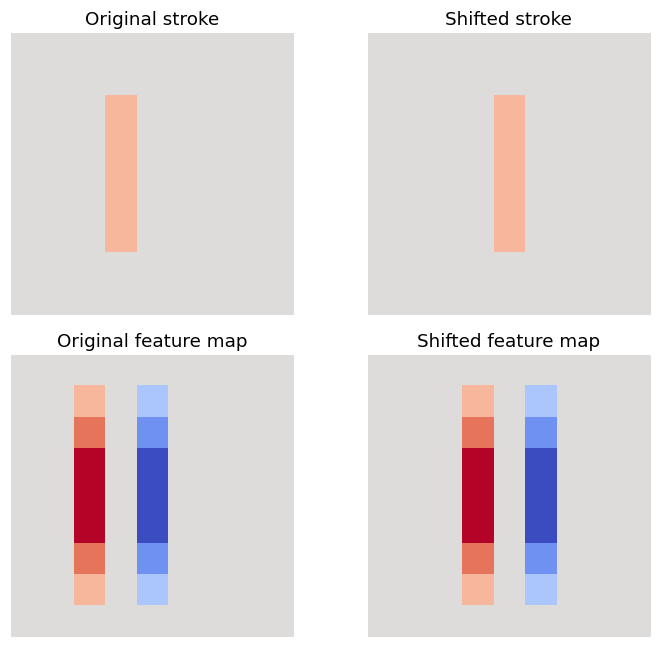

In [7]:
def shift_right(values):
    shifted = torch.zeros_like(values)
    shifted[..., 1:] = values[..., :-1]
    return shifted

stroke = torch.zeros(1, 1, 9, 9)
stroke[0, 0, 2:7, 3] = 1
shifted_stroke = shift_right(stroke)
stroke_features = F.conv2d(stroke, edge_kernel, padding=1)
shifted_features = F.conv2d(shifted_stroke, edge_kernel, padding=1)
expected_shifted_features = shift_right(stroke_features)
torch.testing.assert_close(shifted_features, expected_shifted_features)
assert not torch.equal(stroke_features, shifted_features)
boundary_image = torch.ones(1, 1, 5, 5)
sum_kernel = torch.ones(1, 1, 3, 3)
shift_then_filter = F.conv2d(shift_right(boundary_image), sum_kernel, padding=1)
filter_then_shift = shift_right(F.conv2d(boundary_image, sum_kernel, padding=1))
assert not torch.equal(shift_then_filter, filter_then_shift)
print('Interior shift maximum discrepancy:', (shifted_features-expected_shifted_features).abs().max().item())
print('Boundary counterexample maximum discrepancy:', (shift_then_filter-filter_then_shift).abs().max().item())
fig, axes = plt.subplots(2, 2, figsize=(7, 6))
for ax, values, title in zip(axes.flat, [stroke, shifted_stroke, stroke_features, shifted_features],
                            ['Original stroke', 'Shifted stroke', 'Original feature map', 'Shifted feature map']):
    ax.imshow(values[0, 0], cmap='coolwarm', vmin=-3, vmax=3)
    ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

## Pooling can hide some movement and reveal other movement

Max pooling with 2 × 2 windows and stride two returns the largest value in each window. In a 4 × 4 image, place a bright pixel at row one, column zero. It lies in the top-left window, producing pooled map $[[1,0],[0,0]]$. Shift it one pixel right to column one: it is still inside the same window, so the pooled map is unchanged.

Start instead at row one, column one and shift right to column two. The bright pixel crosses a pooling boundary and produces $[[0,1],[0,0]]$. The same one-pixel movement has a different effect depending on its position relative to the window grid.

Global average pooling over the unpooled image gives $1/16$ in all these cases because the single bright pixel remains inside the image. That statistic is unchanged under these particular shifts, but it also cannot tell where the pixel was. Pooling trades information for a summary; it does not make every classifier invariant to all translations, rotations, scale changes, or cropping.

In [8]:
dot_a = torch.zeros(1, 1, 4, 4); dot_a[0, 0, 1, 0] = 1
within = shift_right(dot_a)
across = shift_right(within)
pooled_a = F.max_pool2d(dot_a, 2)
pooled_within = F.max_pool2d(within, 2)
pooled_across = F.max_pool2d(across, 2)
torch.testing.assert_close(pooled_a, pooled_within)
assert not torch.equal(pooled_within, pooled_across)
torch.testing.assert_close(pooled_across, torch.tensor([[[[0., 1.], [0., 0.]]]]))
for values in [dot_a, within, across]:
    torch.testing.assert_close(values.mean(), torch.tensor(1/16))
print('Before / within-window shift:\n', pooled_a[0, 0])
print('After crossing a window boundary:\n', pooled_across[0, 0])
print('Global mean in all three cases:', dot_a.mean().item())

Before / within-window shift:
 tensor([[1., 0.],
        [0., 0.]])
After crossing a window boundary:
 tensor([[0., 1.],
        [0., 0.]])
Global mean in all three cases: 0.0625


## Batch images without mixing their identities

A batch stacks complete images on a new leading axis. It does not concatenate colors into channels or join pictures side by side. For two RGB images of size 4 × 4, the input shape is `(2, 3, 4, 4)`. A convolution with two output filters produces `(2, 2, 4, 4)` when its spatial settings preserve the grid.

Each image uses the same filter weights but receives its own output. For an ordinary convolution, processing both together must equal concatenating their individual results. Reordering batch rows should reorder output rows, and modifying one image should not affect the other's response. Training-mode BatchNorm is a separate operation that can couple examples through batch statistics; the independence demonstration here uses convolution only.

Forward propagation calculates activations and does not modify these convolution parameters. A loss and backward pass calculate gradients; an optimizer step is still required to learn. Shared filters accumulate training evidence across spatial locations and examples, which is one reason this image representation is useful to an ANN.

In [9]:
batch = torch.cat([image, image.flip(-1)], dim=0)
shared_layer = nn.Conv2d(3, 2, 3, padding=1)
parameters_before = {name: p.detach().clone() for name, p in shared_layer.named_parameters()}
with torch.no_grad():
    batched_output = shared_layer(batch)
    separate_output = torch.cat([shared_layer(batch[i:i+1]) for i in range(2)])
    torch.testing.assert_close(batched_output, separate_output)
    torch.testing.assert_close(shared_layer(batch.flip(0)), batched_output.flip(0))
    changed_batch = batch.clone(); changed_batch[0] = 0
    changed_output = shared_layer(changed_batch)
    torch.testing.assert_close(changed_output[1], batched_output[1])
for name, p in shared_layer.named_parameters():
    torch.testing.assert_close(p, parameters_before[name])
assert batched_output.shape == (2, 2, 4, 4)
print('Batch input/output:', tuple(batch.shape), tuple(batched_output.shape))
print('Batched and individual predictions agree; other-image output and weights are unchanged.')

Batch input/output: (2, 3, 4, 4) (2, 2, 4, 4)
Batched and individual predictions agree; other-image output and weights are unchanged.


## Read the verified calculations

All 9 code cells passed in a fresh in-process CPU kernel. Every pixel survived the correct layout round trip; the reshape-only counterexample produced a different image. Manual channel gradients matched autograd, and the illustrative SGD step reduced loss from 0.493249 to 0.468140, with the score rising from 0.450000 to 0.515802.

The interior shift check matched exactly, the boundary counterexample differed, and pooling preserved a within-window movement while changing after a boundary crossing. Batched convolution agreed with separate per-image calculations and did not change stored parameters. These are verified mechanisms rather than trained-classifier performance claims.

## Connect the representation to a useful image system

An image pipeline must preserve an agreed meaning from capture through inference: channel order, axis order, pixel range, resizing or cropping, and any normalization. Resizing changes the sampled image; stretching can change geometry, cropping can remove the object, and channel swaps can change the detector response. Those choices belong to the model's input contract and need evaluation on representative examples.

CNNs are useful because local connectivity and shared filters match many visual patterns. The same edge detector can contribute evidence at several positions, and deeper nonlinear layers can combine those local responses into larger structures. These assumptions reduce the number of independent weights compared with dense connectivity, but they do not establish accuracy by themselves.

The worked calculations show how pixel values become scores and how one labeled error can update a filter. The controlled shift experiments show both the useful behavior and its limits. To claim an image-recognition system works, train on appropriate data, compare with simpler alternatives, and evaluate separately on the conditions where it will be used.